The contents of this notebook were created with assistance from Claude generative AI.

# 00 · START HERE — NYC Congestion Pricing Stance Analysis

**Read this first.** This folder analyzes Reddit stance toward NYC congestion
pricing (the Central Business District Tolling Program) over **time** and across
**geography**, using subreddits as a geographic proxy.

Data source: `stance_predictions_modernbert_tuned.parquet` (427k posts/comments, each
labeled **pro / anti / neutral / off-topic** with class probabilities), spanning
**Jan 2023 → Apr 2025+**. The headline event is the **Jan 5 2025 launch**.

Everything is **Matplotlib + pandas**, runs locally, and uploads cleanly to
**Deepnote**.

In [1]:
import sys; sys.path.append(".")        # so config / analysis_utils import on Deepnote too
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import config as C
import analysis_utils as A
A.apply_style()
pd.set_option("display.width", 120)

## The team palette

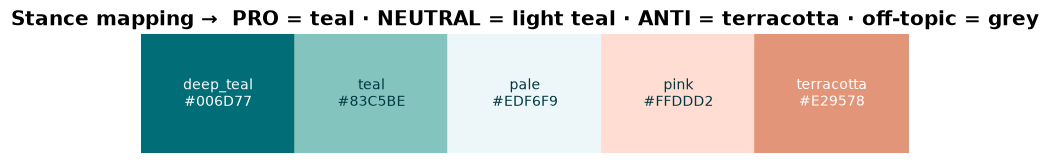

In [2]:
fig, ax = plt.subplots(figsize=(9, 1.4))
for i,(name,hexc) in enumerate(C.PALETTE.items()):
    ax.add_patch(plt.Rectangle((i,0),1,1,color=hexc))
    ax.text(i+0.5,0.5,f"{name}\n{hexc}",ha="center",va="center",
            color="white" if name in ("deep_teal","terracotta") else "#003840",fontsize=9)
ax.set_xlim(0,len(C.PALETTE)); ax.set_ylim(0,1); ax.axis("off")
ax.set_title("Stance mapping →  PRO = teal · NEUTRAL = light teal · ANTI = terracotta · off-topic = grey")
plt.show()

## How to use this folder

1. **Run `01_data_prep.ipynb` once.** It scans the raw data and writes small
   cached rollups into `rollups/`. Every other notebook reloads those in <1s.
   Re-run it only when the source parquet changes (it skips work if caches exist
   — set `REBUILD = True` to force).
2. Open any analysis notebook (02–07). They're independent; run top-to-bottom.
3. **All knobs live in `config.py`** — paths, palette, geography map, day-parts,
   and the event timeline. Edit there, re-run a notebook, done.

## The notebooks

| # | Notebook | What it's for |
|---|----------|---------------|
| 01 | **data_prep** | Builds + caches hourly rollups (numerator from the stance file, denominators from the 18.4M-row unfiltered files). Run first. |
| 02 | **stance_over_time** | The spine: pro/anti/neutral share + a single *net stance index* over daily/weekly/monthly grains, annotated with events. Includes interrupted-time-series (segmented regression) at the launch. |
| 03 | **geography** | Stance by geo tier, the **CBD vs Non-CBD Manhattan** split, individual Manhattan subreddits, and pre/post-launch comparisons per tier with significance tests. |
| 04 | **event_study** | Aligned ±window views around each event. **Has an editable section to drop in your own outlier events** and re-plot at any grain. |
| 05 | **volume_salience** | *Share of conversation* (topic items ÷ all activity), raw volume, off-topic share, and the day-part volume profile. |
| 06 | **polarization_intensity** | The soft-probability story: stance *distributions*, model *uncertainty* (entropy), and *bimodality* over time — "did it get more polarized," not just "did the mean move." |
| 07 | **stance_fingerprint** | Per-subreddit stance heatmap + ranking, and an activist-vs-geographic lead/lag check around the launch. |

## ⚠️ Caveats & gotchas — please read before drawing conclusions

- **Off-topic dominates (~59% of rows).** It's the model's relevance signal, not
  a stance. All stance shares are computed **among on-topic items only**
  (pro/anti/neutral). Off-topic is tracked *separately* as a salience indicator
  (notebook 05). Don't mix it into stance shares.
- **Subreddit volume is wildly uneven** — `nyc` has ~106k items; `r/manhattan`
  only **288** over 3+ years; some (`yonkers`, `montclair`) have single digits.
  Per-subreddit lines are fragile. We (a) show **Wilson confidence intervals**
  everywhere and (b) **suppress cells with n < `C.MIN_N`** (default 30). Prefer
  the **geo-tier rollups** for claims; treat single-subreddit lines as colour.
- **CBD-Manhattan is THIN.** The below-60th-St bucket is essentially just
  `r/eastvillage` (~136 items total). The CBD-vs-Non-CBD contrast is
  *suggestive, not conclusive*; its error bars will be wide on purpose.
- **`r/manhattan` is island-ambiguous** — it's kept in its own `Manhattan-whole`
  CBD bucket, not forced above/below 60th.
- **Times are NYC-local.** `created_utc` (UTC) is converted to
  `America/New_York` *before* day/day-part bucketing, with DST handled.
- **"Share of conversation"** = topic items ÷ *all* items in that sub/period
  (denominators from the unfiltered files). It corrects for subs that simply
  grew over time. Raw volume alone would fake rising interest.
- **Deepnote paths:** if the data mounts somewhere other than the default, set
  the `MADS_DATA_ROOT` env var (or edit `config.py`). The `rollups/` cache is
  portable — if you upload it, notebooks 02–07 run without the big raw files.
- **Stats are paired with visuals**, not decorative: chi-square / two-proportion
  tests, Wilson & bootstrap CIs, segmented regression, KS tests. Effect sizes
  are reported alongside p-values, and multiple comparisons get BH correction.

## Data dictionary — `stance_predictions_modernbert_tuned.parquet`

| column | meaning |
|---|---|
| `id` | Reddit fullname-less id of the post/comment |
| `kind` | `post` or `comment` |
| `subreddit` | source subreddit (geographic proxy) |
| `created_utc` | creation time, epoch seconds **UTC** |
| `link_id` | parent submission id (thread key) |
| `stance_pred` | argmax label: `pro` / `anti` / `neutral` / `off-topic` |
| `p_anti`, `p_neutral`, `p_pro`, `p_off_topic` | class probabilities (sum≈1) |

Geography (`geo_tier`, `cbd_zone`, `is_topical`) is attached at load time from
the mapping in `config.py`.